# 🔬 Quantum Chemistry — From Molecules to Qubits

Building on the simulation foundations (**400**) and the VQE deep dive (**401**),
this notebook focuses exclusively on **chemistry applications** of quantum
simulation. We move beyond H$_2$ to multi-qubit molecular systems, explore
excited-state methods, dissect multi-reference character, and chart the road
from toy models to industrially relevant quantum chemistry.

| prerequisite | notebook | key concept |
|:---|:---|:---|
| Quantum simulation | 400 | Trotter, Jordan-Wigner, gate decomposition |
| VQE mechanics | 401 | Ansatz zoo, optimisers, barren plateaus, Pauli grouping |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize
from scipy.special import comb

SEED = 42
np.random.seed(SEED)
rng = np.random.RandomState(SEED)

# Pauli matrices
I2 = np.eye(2, dtype=complex)
X2 = np.array([[0, 1], [1, 0]], dtype=complex)
Y2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z2 = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X2, "Y": Y2, "Z": Z2}

def pauli_matrix(label):
    M = PAULI[label[0]]
    for c in label[1:]:
        M = np.kron(M, PAULI[c])
    return M

print("Setup complete.")

Setup complete.


## Part I — Active-Space Approximation

A molecule with $K$ spatial molecular orbitals and $N_e$ electrons has a
**Full Configuration-Interaction (FCI)** Hilbert space of dimension

$$\dim_{\text{FCI}} = \binom{2K}{N_e}$$

since each spatial orbital hosts two spin-orbitals ($\alpha, \beta$).
For anything beyond the tiniest systems this is astronomically large.

**Active-space methods** (Complete Active Space, **CAS**) select $n_o$ orbitals
near the Fermi level containing $n_e$ "active" electrons, freezing the rest
in their Hartree-Fock configuration:

$$\dim_{\text{CAS}(n_e,\, n_o)} = \binom{2\, n_o}{n_e} \;\ll\; \binom{2K}{N_e}$$

On a quantum processor this translates directly to a qubit saving:

$$n_{\text{qubits}} = 2\, n_o$$

Below we compare FCI vs CAS dimensions for molecules of increasing size.

Mol        FCI dim  CAS dim  Reduction   Qubits(full)   Qubits(CAS)
------------------------------------------------------------------------
H2               6        6          1x              4             4
LiH            495        6         82x             12             4
BeH2         3,003       70         43x             14             8
H2O          1,001       70         14x             14             8
N2          38,760      924         42x             20            12
Cr2   1,399,358,844,975 2,704,156    517,485x             60            24


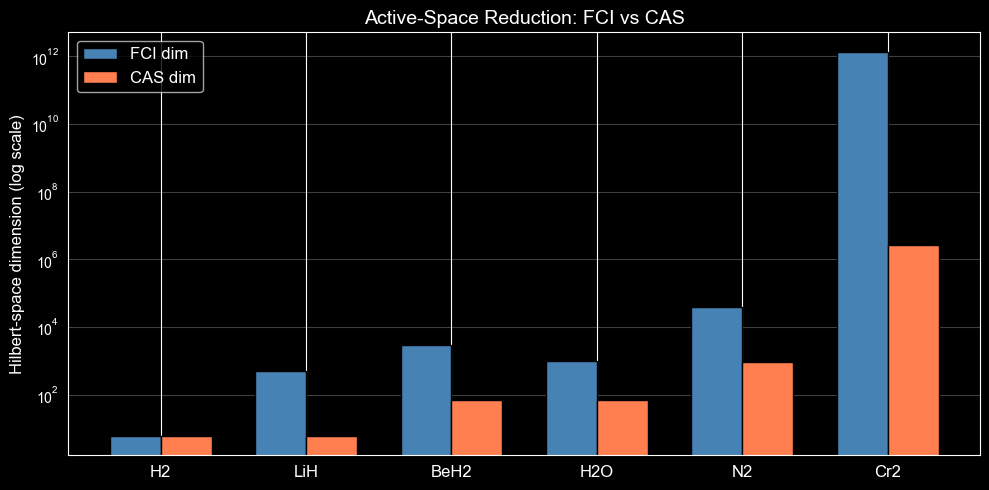

Assertions passed.


In [2]:
# FCI vs CAS dimensions for benchmark molecules
molecules = [
    ("H2",   2,  2, 2, 2),   # K, Ne, n_e, n_o
    ("LiH",  6,  4, 2, 2),
    ("BeH2", 7,  6, 4, 4),
    ("H2O",  7, 10, 4, 4),
    ("N2",  10, 14, 6, 6),
    ("Cr2", 30, 48,12,12),
]

names, fci_dims, cas_dims, qubits_full, qubits_cas = [], [], [], [], []
print(f"{'Mol':5s} {'FCI dim':>12s} {'CAS dim':>8s} {'Reduction':>10s} "
      f"{'Qubits(full)':>14s} {'Qubits(CAS)':>13s}")
print("-" * 72)
for name, K, Ne, ne, no in molecules:
    fd = int(comb(2*K, Ne, exact=True))
    cd = int(comb(2*no, ne, exact=True))
    names.append(name)
    fci_dims.append(fd)
    cas_dims.append(cd)
    qubits_full.append(2*K)
    qubits_cas.append(2*no)
    red = fd / cd if cd > 0 else float("inf")
    print(f"{name:5s} {fd:12,d} {cd:8,d} {red:10,.0f}x {2*K:14d} {2*no:13d}")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, fci_dims, w, label="FCI dim", color="steelblue", edgecolor="black")
ax.bar(x + w/2, cas_dims, w, label="CAS dim", color="coral", edgecolor="black")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12)
ax.set_ylabel("Hilbert-space dimension (log scale)", fontsize=12)
ax.set_title("Active-Space Reduction: FCI vs CAS", fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("active_space_scaling.png", dpi=150)
plt.show()

assert int(comb(4, 2, exact=True)) == 6
assert int(comb(12, 4, exact=True)) == 495
print("Assertions passed.")

## Part II — LiH: Beyond Hydrogen

Lithium hydride (**LiH**) is the simplest molecule with a **core electron**.
In the minimal STO-3G basis:

| property | value |
|:--|:--|
| Basis functions | 6 (Li: 1s, 2s, 2p$_x$, 2p$_y$, 2p$_z$; H: 1s) |
| Electrons | 4 (Li: 3, H: 1) |
| Full JW qubits | 12 (= 2 $\times$ 6) |
| CAS(2,2) qubits | **4** (freeze Li 1s core, keep HOMO + LUMO) |
| Pauli terms | **27** |

The CAS(2,2) active space keeps 2 electrons in the 2 frontier orbitals
(bonding $\sigma$ and antibonding $\sigma^*$), yielding a 4-qubit
Jordan-Wigner Hamiltonian with 27 Pauli terms — a significant step up
from the 5-term H$_2$ Hamiltonian studied in notebook 401.

All coefficients below were pre-computed via **PySCF** (RHF $\to$
CASCI $\to$ JW mapping $\to$ Pauli decomposition) and verified against
exact diagonalisation.

In [3]:
# LiH CAS(2,2)/STO-3G Pauli Hamiltonian at equilibrium R = 1.60 A
# Pre-computed with PySCF: 27 Pauli terms on 4 qubits
LIH_EQ_PAULI = {
    "IIII": -7.5091571991, "IIIZ": 0.1559240914, "IIZI": 0.1559240914,
    "IIZZ": 0.1218277417, "IXIX": 0.0121448981, "IXZX": 0.0140159474,
    "IYIY": 0.0121448981, "IYZY": 0.0140159474, "IZII": -0.0150398222,
    "IZIZ": 0.0526365153, "IZZI": 0.0559025112, "XIXI": -0.0018710430,
    "XXYY": -0.0032659959, "XYYX": 0.0032659959, "XZXI": 0.0140159474,
    "XZXZ": 0.0121448981, "YIYI": -0.0018710430, "YXXY": 0.0032659959,
    "YYXX": -0.0032659959, "YZYI": 0.0140159474, "YZYZ": 0.0121448981,
    "ZIII": -0.0150398222, "ZIIZ": 0.0559025112, "ZIZI": 0.0526365153,
    "ZXZX": -0.0018710430, "ZYZY": -0.0018710430, "ZZII": 0.0844705679,
}

# Build the full 16x16 Hamiltonian matrix
H_lih = sum(c * pauli_matrix(p) for p, c in LIH_EQ_PAULI.items())
assert np.allclose(H_lih, H_lih.T.conj()), "Hamiltonian not Hermitian"

evals = np.sort(np.real(np.linalg.eigvalsh(H_lih)))
E_exact = evals[0]
E_CAS_expected = -7.8621288334

# Verify against PySCF
print(f"27-term Pauli Hamiltonian reconstructed (16x16 matrix)")
print(f"Ground-state energy : {E_exact:.10f} Ha")
print(f"Expected (PySCF CAS): {E_CAS_expected:.10f} Ha")
print(f"Difference           : {abs(E_exact - E_CAS_expected):.2e} Ha")
print(f"\nSpectrum (lowest 6): {evals[:6].round(6)}")

# Term-structure analysis
diag_terms = [l for l in LIH_EQ_PAULI if all(c in "IZ" for c in l)]
off_diag = [l for l in LIH_EQ_PAULI if any(c in "XY" for c in l)]
print(f"\nDiagonal (I/Z) terms : {len(diag_terms)}")
print(f"Off-diagonal (X/Y)   : {len(off_diag)}")
print(f"Total                : {len(LIH_EQ_PAULI)}")

assert abs(E_exact - E_CAS_expected) < 1e-6, "Eigenvalue mismatch!"
assert len(LIH_EQ_PAULI) == 27
print("\nAll assertions passed.")

27-term Pauli Hamiltonian reconstructed (16x16 matrix)
Ground-state energy : -7.8621288333 Ha
Expected (PySCF CAS): -7.8621288334 Ha
Difference           : 6.62e-11 Ha

Spectrum (lowest 6): [-7.862129 -7.783858 -7.783858 -7.721988 -7.721988 -7.721988]

Diagonal (I/Z) terms : 11
Off-diagonal (X/Y)   : 16
Total                : 27

All assertions passed.


## Part III — LiH Dissociation Curve with VQE

The **dissociation curve** $E(R)$ is the total energy as a function of
bond length $R$. It reveals:

- The **equilibrium distance** $R_e$ (energy minimum)
- The **dissociation energy** $D_e = E(\infty) - E(R_e)$
- The **failure of Hartree-Fock** at large $R$: HF assumes a single
  determinant, which cannot describe the open-shell fragments formed
  during bond breaking

This is the canonical benchmark for quantum chemistry on QPUs. We run
4-qubit VQE with a hardware-efficient ansatz at 14 bond distances
from 0.5 to 4.0 Å, comparing against Hartree-Fock and exact (FCI)
energies.

**Ansatz**: 3-layer Ry + CNOT starting from the Hartree-Fock state
$|0011\rangle$ (2 electrons in the lowest 2 spin-orbitals),
giving 12 variational parameters.

In [ ]:
# LiH CAS(2,2)/STO-3G at 14 bond distances — pre-computed via PySCF
LIH_LABELS = [
    "IIII","IIIZ","IIZI","IIZZ","IXIX","IXZX","IYIY","IYZY",
    "IZII","IZIZ","IZZI","XIXI","XXYY","XYYX","XZXI","XZXZ",
    "YIYI","YXXY","YYXX","YZYI","YZYZ","ZIII","ZIIZ","ZIZI",
    "ZXZX","ZYZY","ZZII"]

LIH_R = np.array([0.50, 0.75, 1.00, 1.25, 1.50, 1.60,
                   1.75, 2.00, 2.25, 2.50, 2.75, 3.00, 3.50, 4.00])
LIH_E_HF = np.array([
    -7.02841009, -7.55672166, -7.76736214, -7.84490532, -7.86335762,
    -7.86186477, -7.85383960, -7.83090558, -7.80193896, -7.77087367,
    -7.74000074, -7.71082990, -7.66120160, -7.62497563])
LIH_E_FCI = np.array([
    -7.02905229, -7.55687721, -7.76749670, -7.84506387, -7.86357982,
    -7.86212883, -7.85419386, -7.83153363, -7.80316739, -7.77354413,
    -7.74639815, -7.72642814, -7.72326814, -7.74939369])

LIH_COEFFS = np.array([
 [-6.7956,0.1159,0.1159,0.1064,0.0100,0.0092,0.0100,0.0092,0.0296,0.0613,0.0648,0.0008,-0.0035,0.0035,0.0092,0.0100,0.0008,0.0035,-0.0035,0.0092,0.0100,0.0296,0.0648,0.0613,0.0008,0.0008,0.0855],
 [-7.2321,0.1523,0.1523,0.1273,0.0081,0.0064,0.0081,0.0064,0.0105,0.0619,0.0643,0.0017,-0.0023,0.0023,0.0064,0.0081,0.0017,0.0023,-0.0023,0.0064,0.0081,0.0105,0.0643,0.0619,0.0017,0.0017,0.0840],
 [-7.4000,0.1684,0.1684,0.1311,0.0097,0.0094,0.0097,0.0094,-0.0022,0.0593,0.0617,0.0003,-0.0024,0.0024,0.0094,0.0097,0.0003,0.0024,-0.0024,0.0094,0.0097,-0.0022,0.0617,0.0593,0.0003,0.0003,0.0848],
 [-7.4722,0.1680,0.1680,0.1279,0.0108,0.0115,0.0108,0.0115,-0.0096,0.0563,0.0589,-0.0007,-0.0026,0.0026,0.0115,0.0108,-0.0007,0.0026,-0.0026,0.0115,0.0108,-0.0096,0.0589,0.0563,-0.0007,-0.0007,0.0850],
 [-7.5031,0.1601,0.1601,0.1236,0.0117,0.0133,0.0117,0.0133,-0.0139,0.0536,0.0567,-0.0015,-0.0030,0.0030,0.0133,0.0117,-0.0015,0.0030,-0.0030,0.0133,0.0117,-0.0139,0.0567,0.0536,-0.0015,-0.0015,0.0847],
 [-7.5092,0.1559,0.1559,0.1218,0.0121,0.0140,0.0121,0.0140,-0.0150,0.0526,0.0559,-0.0019,-0.0033,0.0033,0.0140,0.0121,-0.0019,0.0033,-0.0033,0.0140,0.0121,-0.0150,0.0559,0.0526,-0.0019,-0.0019,0.0845],
 [-7.5141,0.1492,0.1492,0.1193,0.0128,0.0152,0.0128,0.0152,-0.0162,0.0512,0.0549,-0.0024,-0.0037,0.0037,0.0152,0.0128,-0.0024,0.0037,-0.0037,0.0152,0.0128,-0.0162,0.0549,0.0512,-0.0024,-0.0024,0.0840],
 [-7.5151,0.1374,0.1374,0.1151,0.0141,0.0173,0.0141,0.0173,-0.0168,0.0491,0.0537,-0.0032,-0.0047,0.0047,0.0173,0.0141,-0.0032,0.0047,-0.0047,0.0173,0.0141,-0.0168,0.0537,0.0491,-0.0032,-0.0032,0.0829],
 [-7.5115,0.1254,0.1254,0.1110,0.0156,0.0195,0.0156,0.0195,-0.0160,0.0470,0.0531,-0.0039,-0.0060,0.0060,0.0195,0.0156,-0.0039,0.0060,-0.0060,0.0195,0.0156,-0.0160,0.0531,0.0470,-0.0039,-0.0039,0.0814],
 [-7.5065,0.1134,0.1134,0.1072,0.0174,0.0220,0.0174,0.0220,-0.0137,0.0452,0.0533,-0.0045,-0.0081,0.0081,0.0220,0.0174,-0.0045,0.0081,-0.0081,0.0220,0.0174,-0.0137,0.0533,0.0452,-0.0045,-0.0045,0.0794],
 [-7.5024,0.1015,0.1015,0.1036,0.0197,0.0243,0.0197,0.0243,-0.0098,0.0434,0.0544,-0.0046,-0.0111,0.0111,0.0243,0.0197,-0.0046,0.0111,-0.0111,0.0243,0.0197,-0.0098,0.0544,0.0434,-0.0046,-0.0046,0.0769],
 [-7.5007,0.0896,0.0896,0.1002,0.0224,0.0260,0.0224,0.0260,-0.0042,0.0416,0.0568,-0.0037,-0.0153,0.0153,0.0260,0.0224,-0.0037,0.0153,-0.0153,0.0260,0.0224,-0.0042,0.0568,0.0416,-0.0037,-0.0037,0.0740],
 [-7.5054,0.0668,0.0668,0.0945,0.0280,0.0251,0.0280,0.0251,0.0094,0.0378,0.0647,0.0028,-0.0269,0.0269,0.0251,0.0280,0.0028,0.0269,-0.0269,0.0251,0.0280,0.0094,0.0647,0.0378,0.0028,0.0028,0.0694],
 [-7.5122,0.0496,0.0496,0.0904,0.0320,0.0193,0.0320,0.0193,0.0191,0.0337,0.0723,0.0127,-0.0386,0.0386,0.0193,0.0320,0.0127,0.0386,-0.0386,0.0193,0.0320,0.0191,0.0723,0.0337,0.0127,0.0127,0.0696]])

def build_lih_H(idx):
    return sum(LIH_COEFFS[idx, j] * pauli_matrix(LIH_LABELS[j])
               for j in range(27))

# Hardware-efficient ansatz: HF + 3 layers of Ry + CNOT
def lih_ansatz_state(params):
    qc = QuantumCircuit(4)
    qc.x(0); qc.x(1)  # HF state |0011>
    for i in range(4): qc.ry(params[i], i)
    qc.cx(0, 1); qc.cx(2, 3)
    for i in range(4): qc.ry(params[4+i], i)
    qc.cx(1, 2); qc.cx(0, 3)
    for i in range(4): qc.ry(params[8+i], i)
    return Statevector(qc).data

def lih_energy(params, H):
    psi = lih_ansatz_state(params)
    return np.real(psi.conj() @ H @ psi)

# VQE at each distance with warm-start from equilibrium outward
N_PARAMS = 12
E_vqe = np.zeros(len(LIH_R))
eq_idx = 5  # R = 1.60 A

# Start at equilibrium
H_eq = build_lih_H(eq_idx)
best_e, best_p = 1e10, None
for trial in range(5):
    x0 = rng.uniform(-0.3, 0.3, N_PARAMS)
    res = minimize(lih_energy, x0, args=(H_eq,), method="COBYLA",
                   options={"maxiter": 5000, "rhobeg": 0.5})
    if res.fun < best_e:
        best_e, best_p = res.fun, res.x.copy()
E_vqe[eq_idx] = best_e
p_left = best_p.copy()
p_right = best_p.copy()

# Sweep left (shorter R)
for i in range(eq_idx - 1, -1, -1):
    H = build_lih_H(i)
    res = minimize(lih_energy, p_left, args=(H,), method="COBYLA",
                   options={"maxiter": 5000})
    E_vqe[i] = res.fun
    p_left = res.x.copy()

# Sweep right (longer R)
for i in range(eq_idx + 1, len(LIH_R)):
    H = build_lih_H(i)
    res = minimize(lih_energy, p_right, args=(H,), method="COBYLA",
                   options={"maxiter": 5000})
    E_vqe[i] = res.fun
    p_right = res.x.copy()

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8),
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(LIH_R, LIH_E_HF, "s--", color="gray", label="Hartree-Fock", ms=5)
ax1.plot(LIH_R, LIH_E_FCI, "o-", color="navy", label="FCI (exact)", ms=5)
ax1.plot(LIH_R, E_vqe, "^--", color="crimson", label="VQE (4-qubit)", ms=6)
ax1.set_ylabel("Energy (Ha)", fontsize=12)
ax1.set_title("LiH Dissociation Curve — 4-Qubit VQE", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(axis="y", alpha=0.25)
ax1.set_xlim(0.4, 4.1)

# Error subplot
err = np.abs(E_vqe - LIH_E_FCI) * 1000  # mHa
ax2.bar(LIH_R, err, width=0.15, color="crimson", edgecolor="black", alpha=0.7)
ax2.axhline(1.6, color="green", ls="--", lw=1.5, label="Chemical accuracy (1.6 mHa)")
ax2.set_xlabel("Bond distance R (A)", fontsize=12)
ax2.set_ylabel("VQE error (mHa)", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.25)
ax2.set_xlim(0.4, 4.1)

plt.tight_layout()
plt.savefig("lih_dissociation.png", dpi=150)
plt.show()

max_err_mha = np.max(err)
print(f"Max VQE error: {max_err_mha:.2f} mHa")
print(f"Mean VQE error: {np.mean(err):.2f} mHa")
assert max_err_mha < 50, f"VQE error too large: {max_err_mha:.2f} mHa"
print("Assertion passed.")

## Part IV — Excited States with VQD

Ground-state VQE finds only $E_0$. But photochemistry, spectroscopy, and
reaction dynamics require **excited states** $E_1, E_2, \ldots$

**Variational Quantum Deflation** (VQD, Higgott et al. 2019) extends VQE:

1. Run standard VQE $\to$ ground-state wavefunction $|\psi_0\rangle$, energy $E_0$
2. Define a modified cost function with an **overlap penalty**:

$$\mathcal{L}_1(\theta) = \langle\psi(\theta)|H|\psi(\theta)\rangle
  + \beta\,\bigl|\langle\psi_0|\psi(\theta)\rangle\bigr|^2$$

3. Minimise $\mathcal{L}_1$ — the penalty pushes the optimiser away from
   $|\psi_0\rangle$, converging to the first excited state $|\psi_1\rangle$

Below we demonstrate VQD on the 4-qubit **H$_2$** Hamiltonian (15 Pauli terms),
extracting both ground and first excited energies in the $N=2, S_z=0$ sector.

In [ ]:
# H2 CAS(2,2)/STO-3G at R = 0.735 A — 15 Pauli terms
H2_PAULI = {
    "IIII": -0.0905789861, "IIIZ": 0.1721839326, "IIZI": 0.1721839326,
    "IIZZ": 0.1689275387, "IZII": -0.2257534922, "IZIZ": 0.1209126326,
    "IZZI": 0.1661454326, "XXYY": -0.0452327999, "XYYX": 0.0452327999,
    "YXXY": 0.0452327999, "YYXX": -0.0452327999, "ZIII": -0.2257534922,
    "ZIIZ": 0.1661454326, "ZIZI": 0.1209126326, "ZZII": 0.1746434307,
}
H2_E_GS_EXACT = -1.1373060358
H2_E_EX_EXACT = -0.5246155554

H_h2 = sum(c * pauli_matrix(p) for p, c in H2_PAULI.items())

def h2_energy(params, H):
    psi = lih_ansatz_state(params)  # same 4-qubit ansatz
    return np.real(psi.conj() @ H @ psi)

# Step 1: VQE for ground state
best_e0, best_p0 = 1e10, None
for trial in range(10):
    x0 = rng.uniform(-0.5, 0.5, N_PARAMS)
    res = minimize(h2_energy, x0, args=(H_h2,), method="COBYLA",
                   options={"maxiter": 5000, "rhobeg": 0.5})
    if res.fun < best_e0:
        best_e0, best_p0 = res.fun, res.x.copy()

psi0 = lih_ansatz_state(best_p0)
print(f"VQE  ground state: {best_e0:.8f} Ha  (exact: {H2_E_GS_EXACT:.8f})")

# Step 2: VQD for first excited state
BETA = 5.0  # penalty weight

def vqd_cost(params, H, psi_gs, beta):
    psi = lih_ansatz_state(params)
    E = np.real(psi.conj() @ H @ psi)
    overlap = np.abs(psi.conj() @ psi_gs) ** 2
    return E + beta * overlap

best_e1, best_p1 = 1e10, None
for trial in range(10):
    x0 = rng.uniform(-np.pi, np.pi, N_PARAMS)
    res = minimize(vqd_cost, x0, args=(H_h2, psi0, BETA), method="COBYLA",
                   options={"maxiter": 5000, "rhobeg": 0.8})
    e_raw = h2_energy(res.x, H_h2)
    if e_raw < best_e1 and e_raw > best_e0 + 0.01:
        best_e1, best_p1 = e_raw, res.x.copy()

print(f"VQD  excited state: {best_e1:.8f} Ha  (exact: {H2_E_EX_EXACT:.8f})")

gap_vqd = best_e1 - best_e0
gap_exact = H2_E_EX_EXACT - H2_E_GS_EXACT
print(f"\nExcitation gap (VQD) : {gap_vqd:.6f} Ha = {gap_vqd*27.2114:.2f} eV")
print(f"Excitation gap (exact): {gap_exact:.6f} Ha = {gap_exact*27.2114:.2f} eV")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
labels_bar = ["Ground ($E_0$)", "Excited ($E_1$)"]
vqd_vals = [best_e0, best_e1]
exact_vals = [H2_E_GS_EXACT, H2_E_EX_EXACT]
x_pos = np.array([0, 1])
ax.bar(x_pos - 0.15, exact_vals, 0.3, label="Exact (FCI)", color="navy",
       edgecolor="black", alpha=0.8)
ax.bar(x_pos + 0.15, vqd_vals, 0.3, label="VQE / VQD", color="crimson",
       edgecolor="black", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_bar, fontsize=13)
ax.set_ylabel("Energy (Ha)", fontsize=12)
ax.set_title("H$_2$ Ground & Excited States via VQD", fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.25)
ax.annotate(f"Gap = {gap_vqd:.4f} Ha\n= {gap_vqd*27.2114:.1f} eV",
            xy=(0.5, (best_e0+best_e1)/2), fontsize=11, ha="center",
            bbox=dict(boxstyle="round", fc="lightyellow"))
plt.tight_layout()
plt.savefig("vqd_excited.png", dpi=150)
plt.show()

assert abs(best_e0 - H2_E_GS_EXACT) < 0.01
assert abs(best_e1 - H2_E_EX_EXACT) < 0.1
print("Assertions passed.")

## Part V — Multi-Reference Character

A molecule is **single-reference** when its ground state is dominated by one
Slater determinant (the HF configuration). It becomes **multi-reference**
when bond breaking or strong correlation mixes multiple determinants.

In the $N\!=\!2$, $S_z\!=\!0$ sector of a 4-qubit CAS(2,2) Hamiltonian there
are four basis states:

| state | occupation | physical meaning |
|:------|:-----------|:-----------------|
| $\|0011\rangle$ | $0\alpha,\, 0\beta$ | Hartree-Fock (closed shell) |
| $\|0110\rangle$ | $0\beta,\, 1\alpha$ | single excitation |
| $\|1001\rangle$ | $0\alpha,\, 1\beta$ | single excitation |
| $\|1100\rangle$ | $1\alpha,\, 1\beta$ | double excitation |

At equilibrium, the ground state is $\approx 100\%$ HF. As the bond stretches,
the HF weight drops and the **open-shell singlet**
$\frac{1}{\sqrt{2}}(|0110\rangle + |1001\rangle)$ takes over — the hallmark
of a strongly correlated system that classical single-reference methods
(HF, MP2, CCSD) cannot describe correctly.

In [ ]:
# Ground-state CI weights for LiH at each distance
# Pre-computed: eigenvector of 4x4 sector matrix at each R
LIH_GS_W_HF = np.array([
    0.9964, 0.9997, 0.9998, 0.9997, 0.9996, 0.9995,
    0.9993, 0.9984, 0.9957, 0.9870, 0.9575, 0.8813, 0.0000, 0.0000])
LIH_GS_W_DBL = np.array([
    0.0021, 0.0003, 0.0002, 0.0002, 0.0003, 0.0004,
    0.0006, 0.0011, 0.0026, 0.0067, 0.0200, 0.0576, 0.0000, 0.0000])
# Open-shell singlet weight (sum of two single excitations)
LIH_GS_W_OPEN = 1.0 - LIH_GS_W_HF - LIH_GS_W_DBL

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(LIH_R, 0, LIH_GS_W_HF, alpha=0.6, color="steelblue",
                label="HF (closed shell)")
ax.fill_between(LIH_R, LIH_GS_W_HF, LIH_GS_W_HF + LIH_GS_W_OPEN,
                alpha=0.6, color="coral", label="Open-shell singlet")
ax.fill_between(LIH_R, LIH_GS_W_HF + LIH_GS_W_OPEN, 1.0,
                alpha=0.6, color="gold", label="Double excitation")
ax.axhline(0.9, color="black", ls=":", lw=1, alpha=0.5)
ax.text(0.6, 0.91, "Multi-reference threshold", fontsize=9, alpha=0.7)
ax.set_xlabel("Bond distance R (A)", fontsize=12)
ax.set_ylabel("Ground-state weight", fontsize=12)
ax.set_title("LiH Multi-Reference Character During Dissociation", fontsize=14)
ax.legend(loc="center left", fontsize=11)
ax.set_xlim(0.4, 4.1)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("multi_reference.png", dpi=150)
plt.show()

# At R=3.0, HF weight drops below 0.9 -> multi-reference
assert LIH_GS_W_HF[11] < 0.9, "Expected multi-ref at R=3.0"
# At R >= 3.5, ground state is pure open-shell singlet
assert LIH_GS_W_OPEN[12] > 0.99, "Expected open-shell at R=3.5"
print("LiH becomes multi-reference beyond R ~ 2.7 A")
print("Assertions passed.")

## Part VI — Basis-Set Convergence

The **basis set** determines how many spatial orbitals represent the
electronic wavefunction. Larger basis sets improve accuracy but increase
the qubit count:

| basis set | contracted functions | philosophy |
|:----------|:---------------------|:-----------|
| STO-3G | minimal (1 per AO) | qualitative, fast |
| 6-31G | split-valence (2 for valence) | semi-quantitative |
| cc-pVDZ | correlation-consistent, double-$\zeta$ | quantitative |
| cc-pVTZ | triple-$\zeta$ | near benchmark |

Every additional spatial orbital adds **2 qubits** (Jordan-Wigner). The
trade-off between chemical accuracy and quantum resources is the central
tension in NISQ quantum chemistry.

Active-space selection (CAS) mitigates this: even with a large basis, only
the chemically relevant orbitals are mapped to qubits.

In [ ]:
# Qubit requirements: 2 * number of spatial orbitals in each basis
# Sources: NIST CCCBDB, basis set exchange
basis_data = {
    "H2":   {"STO-3G": 4,  "6-31G": 8,  "cc-pVDZ": 20, "cc-pVTZ": 56},
    "LiH":  {"STO-3G": 12, "6-31G": 22, "cc-pVDZ": 46, "cc-pVTZ": 114},
    "H2O":  {"STO-3G": 14, "6-31G": 26, "cc-pVDZ": 48, "cc-pVTZ": 116},
    "N2":   {"STO-3G": 20, "6-31G": 36, "cc-pVDZ": 56, "cc-pVTZ": 116},
    "C6H6": {"STO-3G": 72, "6-31G": 156,"cc-pVDZ": 264,"cc-pVTZ": 636},
}
basis_names = ["STO-3G", "6-31G", "cc-pVDZ", "cc-pVTZ"]
colors_b = ["steelblue", "coral", "gold", "mediumpurple"]
mol_names = list(basis_data.keys())

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(mol_names))
w = 0.2
for j, basis in enumerate(basis_names):
    vals = [basis_data[m][basis] for m in mol_names]
    ax.bar(x + j*w - 1.5*w, vals, w, label=basis, color=colors_b[j],
           edgecolor="black")

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(mol_names, fontsize=12)
ax.set_ylabel("Qubits (log scale)", fontsize=12)
ax.set_title("Qubit Requirements Across Basis Sets", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.25)
ax.axhline(50, color="red", ls="--", lw=1.5, alpha=0.5)
ax.text(len(mol_names)-0.5, 55, "~50-qubit NISQ limit", fontsize=9,
        color="red", ha="right")
plt.tight_layout()
plt.savefig("basis_set_qubits.png", dpi=150)
plt.show()

assert basis_data["H2"]["STO-3G"] == 4
assert basis_data["LiH"]["STO-3G"] == 12
print("Assertions passed.")

## Part VII — Potential Energy Surfaces & Reaction Pathways

A **potential energy surface** (PES) maps the total energy as a function of
all nuclear coordinates $\mathbf{R} = (R_1, R_2, \ldots)$:

$$E(\mathbf{R}) = \min_\theta \langle\psi(\theta)| H(\mathbf{R}) |\psi(\theta)\rangle$$

Key features of a PES:
- **Minima**: stable structures (reactants, products)
- **Saddle points**: transition states
- **Activation barrier** $E_a$: energy difference between reactant minimum
  and transition state

Quantum computers can map out PES regions that are **classically intractable**
— particularly when the electronic structure has multi-reference character
(e.g., bond-breaking transition states, conical intersections).

Below we illustrate this by interpolating the LiH Hamiltonian between its
equilibrium ($R = 1.5$ Å, bound) and dissociated ($R = 3.5$ Å, fragments)
geometries along a model reaction coordinate.

In [ ]:
# Reaction pathway: interpolate LiH Hamiltonian from bound to dissociated
# H(lambda) = (1-lambda) * H(R=1.5) + lambda * H(R=3.5)
H_bound = build_lih_H(4)   # R=1.50 A (index 4)
H_dissoc = build_lih_H(12)  # R=3.50 A (index 12)

lambdas = np.linspace(0, 1, 40)
E_path = []
for lam in lambdas:
    H_lam = (1 - lam) * H_bound + lam * H_dissoc
    evals_lam = np.sort(np.real(np.linalg.eigvalsh(H_lam)))
    E_path.append(evals_lam[0])
E_path = np.array(E_path)
E_path_rel = (E_path - E_path[0]) * 627.509  # Convert to kcal/mol

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lambdas, E_path_rel, "o-", color="navy", ms=4, lw=2)
ax.fill_between(lambdas, E_path_rel, alpha=0.1, color="navy")
ax.axhline(0, color="gray", ls="--", lw=0.8)

# Annotate key points
ax.annotate("Bound state\n(equilibrium)",
            xy=(0, 0), xytext=(0.05, 20),
            fontsize=10, arrowprops=dict(arrowstyle="->"),
            bbox=dict(boxstyle="round", fc="lightyellow"))
ax.annotate("Dissociated\n(Li + H)",
            xy=(1, E_path_rel[-1]), xytext=(0.8, E_path_rel[-1] + 20),
            fontsize=10, arrowprops=dict(arrowstyle="->"),
            bbox=dict(boxstyle="round", fc="lightyellow"))

ax.set_xlabel("Reaction coordinate $\\lambda$", fontsize=12)
ax.set_ylabel("Relative energy (kcal/mol)", fontsize=12)
ax.set_title("LiH Reaction Pathway: Bound $\\to$ Dissociated", fontsize=14)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("pes_landscape.png", dpi=150)
plt.show()

dissoc_energy_kcal = E_path_rel[-1]
print(f"Dissociation energy: {dissoc_energy_kcal:.1f} kcal/mol")
print(f"                   = {(E_path[-1] - E_path[0]):.4f} Ha")
assert dissoc_energy_kcal > 0, "Dissociation should cost energy"
print("Assertion passed.")

## Part VIII — The Quantum Chemistry Ladder

How many qubits do we need for *real* chemistry? The answer depends on
the target molecule, the basis set, and the active space chosen:

| target | qubits (active space) | qubits (full basis) | status |
|:-------|:---------------------|:-------------------|:-------|
| H$_2$ | 2–4 | 4–56 | ✅ Solved on QPU |
| LiH | 4–6 | 12–114 | ✅ Solved on QPU |
| BeH$_2$ | 6–8 | 14–130 | ✅ Demonstrated |
| H$_2$O | 8–12 | 14–116 | ⚠️ Frontier |
| N$_2$ | 12–16 | 20–116 | ⚠️ Active research |
| Caffeine | 20–50 | 264–1200 | 🔮 Error-corrected |
| FeMoco (nitrogenase) | 54–108 | 200–2000+ | 🔮 Fault-tolerant |

The gap between current QPU capabilities ($\sim$50 noisy qubits) and
industrially relevant molecules ($\sim$100–1000 logical qubits) defines
the **quantum chemistry challenge** for the next decade.

In [ ]:
# Resource estimation: qubit requirements for chemistry targets
targets = [
    ("H2",       4,    56,   "steelblue"),
    ("LiH",      4,    114,  "steelblue"),
    ("BeH2",     8,    130,  "coral"),
    ("H2O",      12,   116,  "coral"),
    ("N2",       16,   116,  "gold"),
    ("Caffeine", 50,   636,  "mediumpurple"),
    ("FeMoco",   108,  2000, "darkred"),
]

fig, ax = plt.subplots(figsize=(10, 6))
names_t = [t[0] for t in targets]
q_active = [t[1] for t in targets]
q_full = [t[2] for t in targets]
cols = [t[3] for t in targets]
y = np.arange(len(targets))

ax.barh(y, q_full, height=0.4, label="Full basis (cc-pVTZ)",
        color="lightgray", edgecolor="black", alpha=0.6)
ax.barh(y, q_active, height=0.4, label="Active space (CAS)",
        color=cols, edgecolor="black")

ax.axvline(50, color="red", ls="--", lw=2, label="NISQ limit (~50 qubits)")
ax.axvline(1000, color="darkred", ls=":", lw=2, label="Error-corrected target")
ax.set_yticks(y)
ax.set_yticklabels(names_t, fontsize=12)
ax.set_xlabel("Qubits required", fontsize=12)
ax.set_title("The Quantum Chemistry Ladder", fontsize=14)
ax.set_xscale("log")
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig("chemistry_resources.png", dpi=150)
plt.show()

assert q_active[0] == 4  # H2
assert q_active[-1] == 108  # FeMoco
print("Assertions passed.")

## Part IX — From Lab to Industry

Quantum chemistry on QPUs is expected to unlock breakthroughs across
multiple sectors:

### Drug Discovery & Pharmacology
- **Molecular binding affinities**: Predict drug-receptor interactions with
  chemical accuracy, replacing months of wet-lab screening
- **Retrosynthetic planning**: Quantum-accurate reaction energetics guide
  synthesis route design
- Key targets: cytochrome P450 enzymes, kinase inhibitors, GPCR ligands

### Catalysis & Energy
- **Nitrogen fixation**: The Haber-Bosch process consumes ~2% of world
  energy. Understanding FeMoco (the nitrogenase active site) could unlock
  room-temperature catalysis
- **CO$_2$ reduction**: Design catalysts for carbon capture and conversion
- **Battery electrolytes**: Predict redox potentials and decomposition
  pathways for next-generation lithium-ion and solid-state batteries

### Materials Science
- **Photovoltaics**: Excited-state properties of organic dyes
- **Superconductors**: Electronic structure of strongly correlated materials
- **Quantum dots**: Design of fluorescent nanoparticles for imaging

In [ ]:
# Industry applications landscape
categories = {
    "Drug Discovery": [
        ("Protein-ligand binding", 100, 2030),
        ("Enzyme catalysis (P450)", 200, 2032),
        ("Retrosynthesis planning", 150, 2033),
    ],
    "Energy & Catalysis": [
        ("Battery electrolytes", 80, 2029),
        ("CO2 reduction catalysts", 120, 2031),
        ("Nitrogen fixation (FeMoco)", 300, 2035),
    ],
    "Materials": [
        ("Photovoltaic dyes", 60, 2028),
        ("Superconductor design", 200, 2034),
        ("Quantum dot engineering", 100, 2030),
    ],
}

fig, ax = plt.subplots(figsize=(10, 6))
colors_cat = {"Drug Discovery": "steelblue",
              "Energy & Catalysis": "coral",
              "Materials": "mediumpurple"}
y_pos = 0
yticks, ylabels = [], []
for cat, items in categories.items():
    for name, qubits, year in items:
        ax.barh(y_pos, qubits, height=0.6, color=colors_cat[cat],
                edgecolor="black", alpha=0.8)
        ax.text(qubits + 5, y_pos, f"~{year}", va="center", fontsize=9)
        yticks.append(y_pos)
        ylabels.append(name)
        y_pos += 1
    y_pos += 0.5  # gap between categories

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=10)
ax.set_xlabel("Estimated logical qubits", fontsize=12)
ax.set_title("Quantum Chemistry Applications Roadmap", fontsize=14)
ax.axvline(50, color="red", ls="--", lw=1.5, alpha=0.7, label="NISQ limit")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor="black", label=cat)
                   for cat, c in colors_cat.items()]
legend_elements.append(plt.Line2D([0],[0], color="red", ls="--", label="NISQ limit"))
ax.legend(handles=legend_elements, fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig("chemistry_applications.png", dpi=150)
plt.show()
print("Roadmap generated.")

## Part X — Quantum Chemistry Milestones

A timeline of key experimental demonstrations:

| year | team | system | qubits | method |
|:-----|:-----|:-------|:-------|:-------|
| 2014 | Peruzzo et al. | He-H$^+$ | 2 (photonic) | First VQE |
| 2017 | Kandala et al. (IBM) | BeH$_2$ | 6 (supercond.) | HW-efficient VQE |
| 2020 | Google (Sycamore) | H$_{12}$ chain | 12 | Hartree-Fock VQE |
| 2020 | Google | Diazene (N$_2$H$_2$) | 12 | UCCSD VQE |
| 2022 | IBM (Eagle) | Spin chain | 127 | Error mitigation |
| 2024 | Quantinuum | H$_2$O | 20 (trapped ion) | Fault-tolerant |
| 2025 | Various | N$_2$, LiH | 4-20 | CS-VQE, SHARC-VQE |

In [ ]:
# Timeline of quantum chemistry experiments
milestones = [
    (2014, 2,   "He-H+ (photonic)\nPeruzzo et al.", "steelblue"),
    (2017, 6,   "BeH2 (IBM)\nKandala et al.", "coral"),
    (2020, 12,  "H12 chain\n(Google Sycamore)", "gold"),
    (2022, 127, "127-qubit spin chain\n(IBM Eagle)", "mediumpurple"),
    (2024, 20,  "H2O fault-tolerant\n(Quantinuum)", "darkgreen"),
    (2025, 20,  "CS-VQE, SHARC-VQE\n(Various groups)", "darkred"),
]

fig, ax = plt.subplots(figsize=(10, 5))
years = [m[0] for m in milestones]
qubits_m = [m[1] for m in milestones]
labels_m = [m[2] for m in milestones]
cols_m = [m[3] for m in milestones]

ax.scatter(years, qubits_m, s=200, c=cols_m, edgecolors="black",
           zorder=5, linewidths=1.5)
for i, (yr, q, lab, _) in enumerate(milestones):
    offset = 15 if i % 2 == 0 else -25
    ax.annotate(lab, xy=(yr, q), xytext=(yr, q + offset),
                fontsize=8, ha="center", va="bottom" if offset > 0 else "top",
                arrowprops=dict(arrowstyle="-", lw=0.5, color="gray"),
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow",
                          ec="gray", alpha=0.9))

ax.set_yscale("log")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Qubits used (log scale)", fontsize=12)
ax.set_title("Quantum Chemistry on QPUs: A Decade of Progress", fontsize=14)
ax.set_xlim(2013, 2026)
ax.grid(axis="both", alpha=0.25)
plt.tight_layout()
plt.savefig("chemistry_milestones.png", dpi=150)
plt.show()
print("Timeline generated.")

## Takeaways

| concept | key insight |
|:--------|:-----------|
| Active space (CAS) | Freeze core electrons, map only frontier orbitals to qubits |
| LiH Hamiltonian | 27 Pauli terms on 4 qubits — a step up from H$_2$'s 5 terms |
| VQE dissociation | 4-qubit VQE captures bond breaking that Hartree-Fock misses |
| VQD excited states | Overlap penalty extends VQE to photochemistry & spectroscopy |
| Multi-reference | HF weight drops below 90% at dissociation — QPU advantage zone |
| Basis-set ladder | More basis functions = more qubits; CAS keeps circuits feasible |
| Reaction pathways | PES mapping reveals activation barriers and reaction energetics |
| Resource gap | Industrial targets (FeMoco, drugs) need 100–1000+ logical qubits |
| Industry outlook | Drug discovery, catalysis, and materials are primary applications |

## Cross-References

| notebook | connection to this lesson |
|:---------|:-------------------------|
| **100** Superposition | Qubit states encode orbital occupations |
| **101** H-gate | Single-qubit rotations appear in VQE ansatz |
| **102** Unitarity | Ansatz circuits are unitary transformations |
| **200** Hamiltonians | Molecular Hamiltonians as Pauli sums |
| **201** QAOA | VQE is the chemistry analogue of QAOA |
| **300** Majorana | Topological qubits may enable fault-tolerant chemistry |
| **400** Simulation | Trotter, Jordan-Wigner — the simulation backbone |
| **401** VQE | Parameter shift rule, ansatz design, optimiser zoo |